<a href="https://colab.research.google.com/github/sonjoy1s/LungCancer/blob/main/LungCancerForPaper.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [145]:
import os
import torch
import torchvision
import matplotlib.pyplot as plt
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision.datasets import ImageFolder
from PIL import Image
import torch.nn as nn
import torch.optim as optim
import kagglehub
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

In [146]:
base_path = kagglehub.dataset_download("rm1000/lung-cancer-histopathological-images")

print("Path to dataset files:", base_path)

Using Colab cache for faster access to the 'lung-cancer-histopathological-images' dataset.
Path to dataset files: /kaggle/input/lung-cancer-histopathological-images


In [147]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [148]:
categories = ['adenocarcinoma','benign','squamous_cell_carcinoma']

In [149]:
# Use a unique variable name for the full list of image paths
full_image_path_list = []
labels = []

# Iterate through each category to build paths
for cls in categories:
    cls_path = os.path.join(base_path, cls)
    if not os.path.isdir(cls_path):
        continue

    for img_name in os.listdir(cls_path):
        full_image_path_list.append(os.path.join(cls_path, img_name)) # Populate the new variable
        labels.append(cls)

df = pd.DataFrame({
    'image': full_image_path_list, # df['image'] will now consistently store actual paths
    'label': labels
})


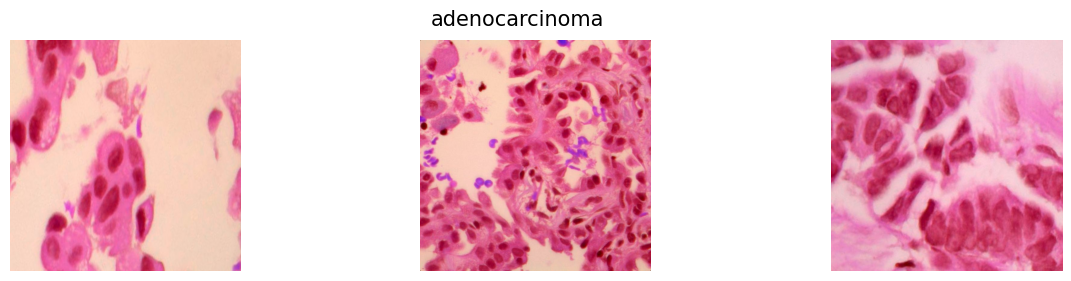

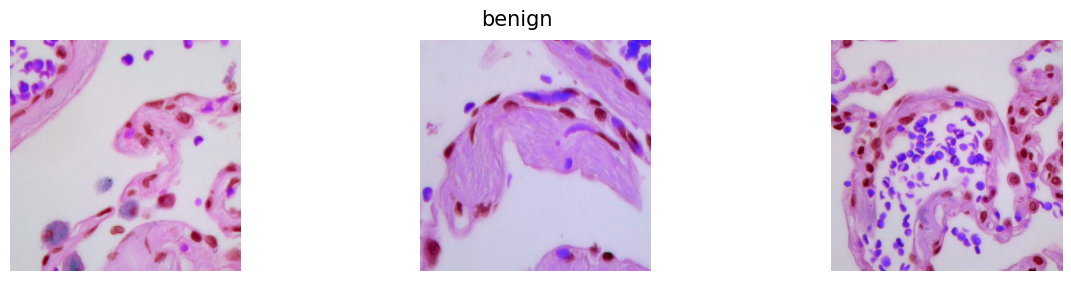

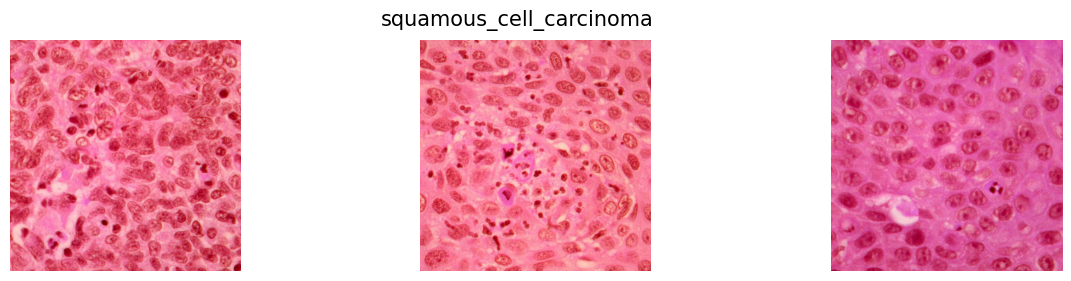

In [150]:
import cv2
import matplotlib.pyplot as plt
for cat in categories:
    # Construct the full path for the current category
    category_path = os.path.join(base_path, cat)
    images = os.listdir(category_path)
    # Initialize a subplot with 1 row and 3 columns
    fig, ax = plt.subplots(1, 3, figsize=(15, 3))
    fig.suptitle(f'{cat}', fontsize=15)

    for i in range(3):
        # Randomly select an image
        img_name = images[np.random.randint(0, len(images))]
        img_path = os.path.join(category_path, img_name)
        img_array = cv2.imread(img_path)

        # Display the image
        ax[i].imshow(img_array)
        ax[i].axis('off')

In [151]:
df['label_id'], uniques = pd.factorize(df['label'])
#df['image_path'],uniques = pd.factorize(df['image'])
print("Class Names:", uniques.tolist())

Class Names: ['adenocarcinoma', 'benign', 'squamous_cell_carcinoma']


In [152]:
from sklearn.model_selection import train_test_split

X = df['image']
y = df['label_id']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [153]:
X_train

,image
5497,/kaggle/input/lung-cancer-histopathological-im...
12677,/kaggle/input/lung-cancer-histopathological-im...
8037,/kaggle/input/lung-cancer-histopathological-im...
6670,/kaggle/input/lung-cancer-histopathological-im...
79,/kaggle/input/lung-cancer-histopathological-im...
...,...
5013,/kaggle/input/lung-cancer-histopathological-im...
4721,/kaggle/input/lung-cancer-histopathological-im...
4788,/kaggle/input/lung-cancer-histopathological-im...
11253,/kaggle/input/lung-cancer-histopathological-im...


In [154]:
import hashlib
import numpy as np

def hash_path(path_string):
    # 'path_string' is directly the image file path from X_train or X_test
    return hashlib.md5(path_string.encode()).hexdigest()

train_hash = set([hash_path(p) for p in X_train]) # X_train contains the image path strings
test_hash = set([hash_path(p) for p in X_test])   # X_test contains the image path strings

print("Overlap:", len(train_hash & test_hash))

Overlap: 0


In [155]:
df['image'].duplicated().sum()

np.int64(0)

In [185]:
df.drop_duplicates(subset='image', inplace=True)

In [186]:
df['label'].value_counts()

,count
label,
adenocarcinoma,5000
benign,5000
squamous_cell_carcinoma,5000


In [157]:
import numpy as np

unique_train = set(X_train)
print(len(unique_train))
unique_test = set(X_test)
print(len(unique_test))

intersection = unique_train.intersection(unique_test)
print(len(intersection))

12000
3000
0


In [158]:
#train_test_split(images)
#normalize(train_data)
#apply_same_transform(test_data)

In [159]:
transform = transforms.Compose(
    [
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
        transforms.Normalize(mean=(0.5)*3,std=(0.5)*3)
    ]
)

In [160]:
from genericpath import isfile

class MyCustomeData(Dataset):
    def __init__(self, dataframe, transform=None):
        self.paths = dataframe['image'].values
        self.labels = dataframe['label_id'].values
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):

        img_path = self.paths[idx]
        img = Image.open(img_path).convert("RGB")

        label = int(self.labels[idx])

        if self.transform:
            img = self.transform(img)

        return img, label

In [161]:
import cv2
import numpy as np

def preprocess_image(image_path):

    img = cv2.imread(image_path)

    # Resize
    img = cv2.resize(img, (128,128))

    # Noise reduction
    img = cv2.GaussianBlur(img, (5,5), 0)

    # Convert to grayscale
    gray = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2GRAY
    )

    # CLAHE enhancement
    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8,8)
    )

    enhanced = clahe.apply(gray)

    # Normalize
    enhanced = enhanced / 255.0

    return enhanced

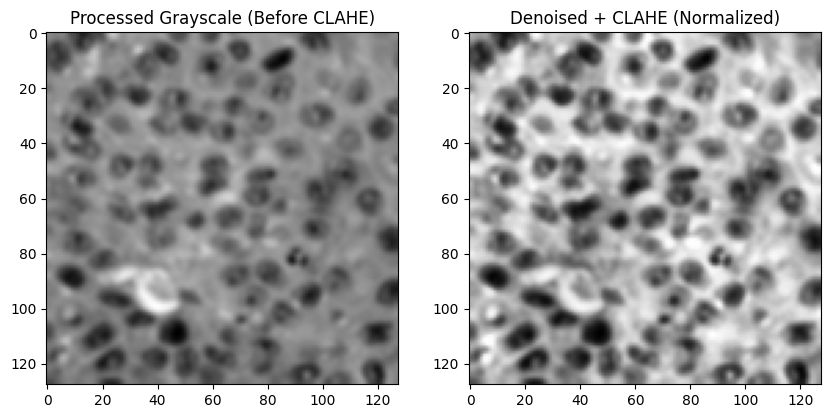

In [162]:
import cv2
if 'img_path' not in locals() or img_path is None:
    if 'df' in globals() and not df.empty:
        img_path = df['image'].iloc[0]
    else:
        # Fallback if df is not available or empty
        print("No image path available. Please ensure 'df' and 'img_path' are defined.")
        # You might want to return or raise an error here if no image can be loaded
        raise ValueError("Cannot display images without a valid image path.")

# Load the image
sample_img_raw = cv2.imread(img_path)

# Apply resize and gaussian blur as done internally by preprocess_image for the 'gray' comparison
resized_img = cv2.resize(sample_img_raw, (128, 128))
blurred_img = cv2.GaussianBlur(resized_img, (5, 5), 0)

# Convert to grayscale to get 'gray'
gray = cv2.cvtColor(blurred_img, cv2.COLOR_BGR2GRAY)

# Get the enhanced image by calling the preprocess_image function
enhanced = preprocess_image(img_path)

fig, ax = plt.subplots(1,2, figsize=(10,5))

ax[0].imshow(gray, cmap='gray')
ax[0].set_title("Processed Grayscale (Before CLAHE)")

ax[1].imshow(enhanced, cmap='gray')
ax[1].set_title("Denoised + CLAHE (Normalized)")

plt.show()

In [163]:
df['label_id'], uniques = pd.factorize(df['label'])

train_dataset_full = MyCustomeData(df.loc[X_train.index], transform)
test_dataset_full = MyCustomeData(df.loc[X_test.index], transform)
num_classes = len(uniques)

print("Number of classes:", num_classes)
print("Full train size:", len(train_dataset_full))
print("Full test size:", len(test_dataset_full))

Number of classes: 3
Full train size: 12000
Full test size: 3000


In [164]:
train_dataset = Subset(train_dataset_full, list(range (0, len(train_dataset_full))))
test_dataset = Subset(test_dataset_full, list(range(0, len(test_dataset_full))))

In [165]:
print("Train size:", len(train_dataset))
print("Test size:", len(test_dataset))

Train size: 12000
Test size: 3000


In [166]:
pin = True if device.type == 'cuda' else False
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, pin_memory=pin)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, pin_memory=pin)

In [167]:
class MyCNNs(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding='same'),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding='same'),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding='same'),
            nn.ReLU(),
            nn.BatchNorm2d(128),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*16*16, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [168]:
model = MyCNNs(num_classes=num_classes).to(device)

In [175]:
learning_rate = 0.0001
epochs = 200
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=0.0001, weight_decay=1e-4)

In [176]:
best_val_loss = float('inf')
patience = 3
counter = 0

train_losses = []
val_losses = []

for epoch in range(epochs):  # max limit

    model.train()
    total_loss = 0

    for batch_features, batch_labels in train_loader:
        batch_features = batch_features.to(device)
        batch_labels = batch_labels.to(device)

        outputs = model(batch_features)
        loss = criterion(outputs, batch_labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    train_loss = total_loss / len(train_loader)
    train_losses.append(train_loss)


    model.eval()
    val_loss = 0

    with torch.no_grad():
        for batch_features, batch_labels in test_loader:
            batch_features = batch_features.to(device)
            batch_labels = batch_labels.to(device)

            outputs = model(batch_features)
            loss = criterion(outputs, batch_labels)

            val_loss += loss.item()

    val_loss = val_loss / len(test_loader)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")


    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        torch.save(model.state_dict(), "best_model.pth")

    else:
        counter += 1

    if counter >= patience:
        print("Early stopping triggered!")
        break

Epoch 1, Train Loss: 0.4569, Val Loss: 0.4096
Epoch 2, Train Loss: 0.4283, Val Loss: 0.3897
Epoch 3, Train Loss: 0.4062, Val Loss: 0.3827
Epoch 4, Train Loss: 0.3932, Val Loss: 0.3729
Epoch 5, Train Loss: 0.3797, Val Loss: 0.3707
Epoch 6, Train Loss: 0.3721, Val Loss: 0.3626
Epoch 7, Train Loss: 0.3661, Val Loss: 0.3827
Epoch 8, Train Loss: 0.3597, Val Loss: 0.3627
Epoch 9, Train Loss: 0.3586, Val Loss: 0.3580
Epoch 10, Train Loss: 0.3530, Val Loss: 0.3579
Epoch 11, Train Loss: 0.3522, Val Loss: 0.3525
Epoch 12, Train Loss: 0.3489, Val Loss: 0.3609
Epoch 13, Train Loss: 0.3482, Val Loss: 0.3578
Epoch 14, Train Loss: 0.3457, Val Loss: 0.3571
Early stopping triggered!


In [177]:
def evaluate(loader):
    model.eval()
    total, correct = 0, 0
    with torch.no_grad():
        for batch_features, batch_labels in loader:
            batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
            outputs = model(batch_features)
            _, predicted = torch.max(outputs, 1)
            total += batch_labels.size(0)
            correct += (predicted == batch_labels).sum().item()
    return correct / total

In [178]:
test_acc = evaluate(test_loader)
print("Test Accuracy:", test_acc)
train_acc = evaluate(train_loader)
print("Train Accuracy:", train_acc)


Test Accuracy: 0.9733333333333334
Train Accuracy: 1.0


In [179]:
from sklearn.metrics import confusion_matrix

def get_all_preds(loader):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for batch_features, batch_labels in loader:
            batch_features = batch_features.to(device)
            outputs = model(batch_features)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(batch_labels.cpu().numpy())
    return np.array(all_labels), np.array(all_preds)

y_true, y_pred = get_all_preds(test_loader)

cm = confusion_matrix(y_true, y_pred)
print(cm)

[[ 939    2   59]
 [   0 1000    0]
 [  19    0  981]]


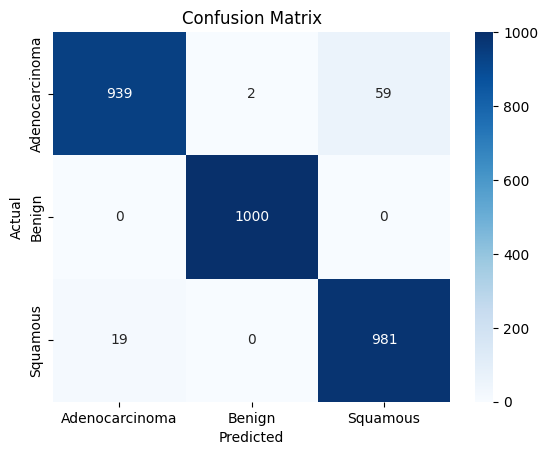

In [187]:
# Visualize the confusion matrix to confirm adeno squamous confusion
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Adenocarcinoma', 'Benign', 'Squamous'],
            yticklabels=['Adenocarcinoma', 'Benign', 'Squamous'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [181]:
from sklearn.metrics import classification_report,roc_auc_score
print(classification_report(y_true, y_pred))


              precision    recall  f1-score   support

           0       0.98      0.94      0.96      1000
           1       1.00      1.00      1.00      1000
           2       0.94      0.98      0.96      1000

    accuracy                           0.97      3000
   macro avg       0.97      0.97      0.97      3000
weighted avg       0.97      0.97      0.97      3000



In [182]:
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score

model.eval()

all_probs = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:

        outputs = model(images)

        probs = F.softmax(outputs, dim=1)

        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

auc = roc_auc_score(
    all_labels,
    all_probs,
    multi_class='ovr'
)

print("AUC:", auc)

AUC: 0.997213


In [183]:
#Find P_Value
import numpy as np
from sklearn.metrics import roc_auc_score

n_permutations = 1000
null_aucs = []

y_true = np.array(all_labels)
y_score = np.array(all_probs)

# convert multi-class probs → use max prob class
y_score_max = np.max(y_score, axis=1)

observed_auc = roc_auc_score(
    y_true,
    y_score,
    multi_class='ovr'
)

for _ in range(n_permutations):
    shuffled_labels = np.random.permutation(y_true)

    auc_perm = roc_auc_score(
        shuffled_labels,
        y_score,
        multi_class='ovr'
    )
    null_aucs.append(auc_perm)

null_aucs = np.array(null_aucs)

# p-value = how many random AUC ≥ observed AUC
p_value = np.mean(null_aucs >= observed_auc)

print("Observed AUC:", observed_auc)
print("P-value:", p_value)

Observed AUC: 0.997213
P-value: 0.0


torch.Size([24, 32, 128, 128])


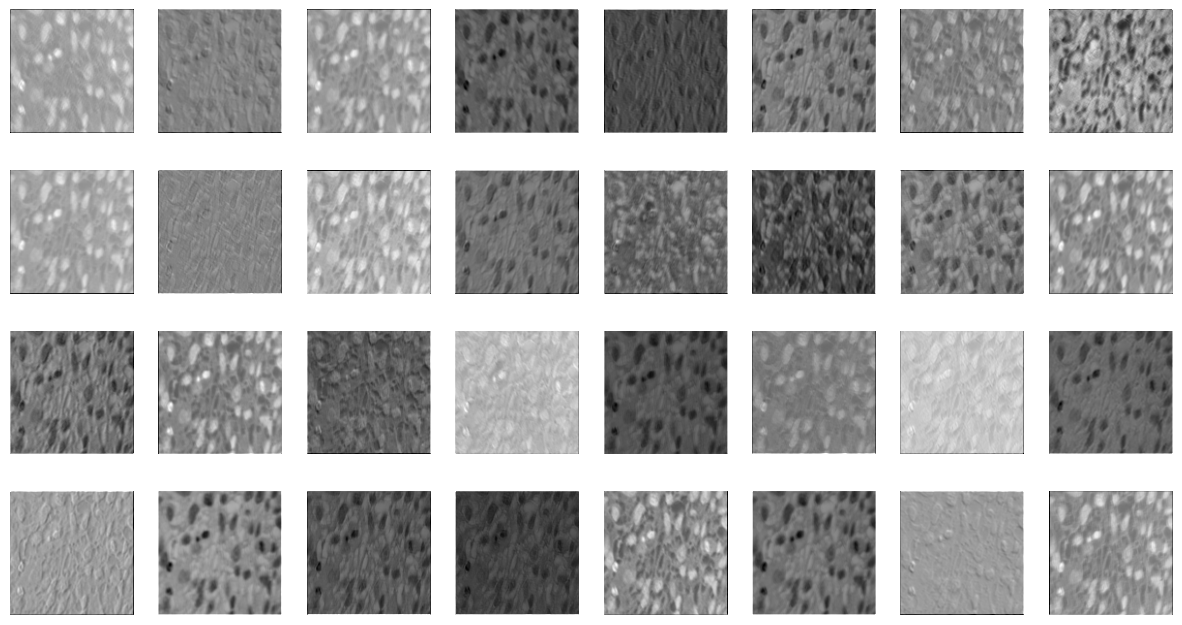

In [184]:
feature_map = model.features[0](images)
print(feature_map.shape)

fig, axes = plt.subplots(4,8, figsize=(15,8))

for i, ax in enumerate(axes.flat):

    ax.imshow(
        feature_map[0,i].detach().cpu().numpy(),
        cmap='gray'
    )

    ax.axis('off')

plt.show()